In [25]:
import torch

image1 = torch.randn(256, 256)
image2 = torch.randn(256, 256)

def fourier_shell_correlation(image1, image2):
    # Transform tensor to complex
    image1 = image1.to(torch.complex64)
    image2 = image2.to(torch.complex64)

    

    # Compute fourier transform
    fft_image1 = torch.fft.fftshift(torch.fft.fft2(image1))
    fft_image2 = torch.fft.fftshift(torch.fft.fft2(image2))
    
    # image2 complex conjugate
    fft_image2_conj = fft_image2.conj()

    # Numerator
    numerador = torch.real(torch.sum(fft_image1 * fft_image2_conj))

    # Den
    denominador_1 = torch.sum(torch.abs(fft_image1) * torch.abs(fft_image1))
    denominador_2 = torch.sum(torch.abs(fft_image2) * torch.abs(fft_image2))
    denominador = torch.sqrt(denominador_1 * denominador_2)

    # Fourier shell correlation
    FSC = torch.div(numerador, denominador)

    return FSC

print(fourier_shell_correlation(image1, image2))

tensor(-0.0011)


In [10]:
import matplotlib.pyplot as plt
import torch
import numpy as np

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])


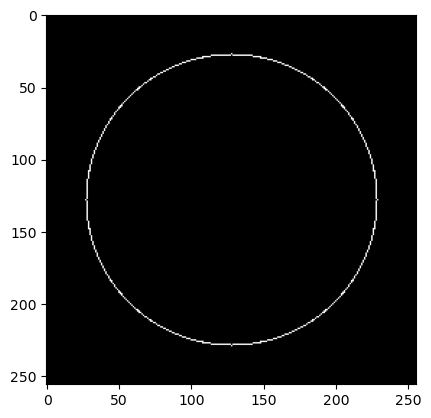

In [28]:

def radial_mask(r, cx=128, cy=128, sx=None, sy=None, delta=1):
    if sx is None:
        sx = torch.arange(0, 256)
    if sy is None:
        sy = torch.arange(0, 256)
    
    ind = (sx.unsqueeze(0) - cx) ** 2 + (sy.unsqueeze(1) - cy) ** 2
    ind1 = ind <= ((r[0] + delta) ** 2)
    ind2 = ind > (r[0] ** 2)
    
    return (ind1 * ind2).float()

# Ejemplo de uso:
r = torch.tensor([100.0])  # Radio de ejemplo
mask = radial_mask(r)
print(mask)

tensor_numpy = np.abs(mask.numpy())

# Mostrar el arreglo usando Matplotlib
plt.imshow(tensor_numpy, cmap='gray')
plt.show()

In [27]:
def get_radial_masks():
    freq_nyq = int(np.floor(int(256) / 2.0))
    radii = np.arange(128).reshape(128, 1)  # image size 256, binning = 3
    radial_masks = np.apply_along_axis(radial_mask, 1, radii, 128, 128, np.arange(0, 256), np.arange(0, 256), 1)
    radial_masks = np.expand_dims(radial_masks, 1)
    radial_masks = np.expand_dims(radial_masks, 1)

    
    spatial_freq = radii.astype(np.float32) / freq_nyq
    spatial_freq = spatial_freq / max(spatial_freq)

    return radial_masks, spatial_freq

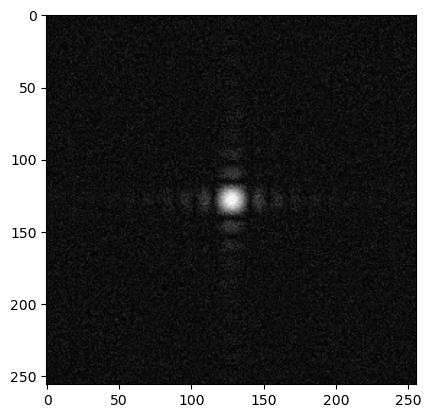

tensor(0.3836)


In [27]:
import matplotlib.pyplot as plt
import torch
import numpy as np

image1 = torch.randn(256, 256)
image1[:20,:20] = 10

fft_image1 = torch.fft.fftshift(torch.fft.fft2(image1.to(torch.complex64)))

tensor_numpy = np.abs(fft_image1.numpy())

# Mostrar el arreglo usando Matplotlib
plt.imshow(tensor_numpy, cmap='gray')
plt.show()

image2 = torch.randn(256, 256)
image2[:20,:20] = 10
print(fourier_shell_correlation(image1, image2))



In [28]:
def fourier_ring_correlation(image1, image2, rn, spatial_freq):
    # Transponer las imágenes para que los canales estén primero
    image1 = image1.permute(0, 3, 1, 2)
    image2 = image2.permute(0, 3, 1, 2)
    
    # Convertir a tipo de dato complejo
    image1 = image1.to(torch.complex64)
    image2 = image2.to(torch.complex64)
    rn = rn.to(torch.complex64)
    
    # Aplicar la transformada de Fourier 2D y centrar las frecuencias
    fft_image1 = torch.fft.fftshift(torch.fft.fft2(image1), dim=(2, 3))
    fft_image2 = torch.fft.fftshift(torch.fft.fft2(image2), dim=(2, 3))

    # Multiplicar en el dominio de la frecuencia (término a término)
    t1 = fft_image1 * rn
    t2 = fft_image2 * rn
    
    # Calcular las correlaciones
    c1 = torch.real(torch.sum(t1 * torch.conj(t2), dim=(2, 3, 4)))
    c2 = torch.sum(torch.abs(t1) ** 2, dim=(2, 3, 4))
    c3 = torch.sum(torch.abs(t2) ** 2, dim=(2, 3, 4))
    
    # Calcular el FRC
    frc = c1 / torch.sqrt(c2 * c3)
    frc = torch.where(torch.isinf(frc), torch.zeros_like(frc), frc)  # inf
    frc = torch.where(torch.isnan(frc), torch.zeros_like(frc), frc)  # nan

    # Calcular la suma de Riemann
    t = spatial_freq
    y = frc
    riemann_sum = torch.sum((t[1:] - t[:-1]) * (y[:-1] + y[1:]) / 2., dim=0)
    
    return riemann_sum


